In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data
df = pd.read_csv('titanic_clean.csv')

# 2. Check the balance of the target variable ('survived')

print(" Class Balance in Original Data : ")

print(df['survived'].value_counts(normalize=True) * 100)

print("\n")

# 3. Written Justification for Stratification

print("JUSTIFICATION:")

print("If we split the data completely randomly, the test set might accidentally get")

print("Using a 'stratified' split forces the Train and Test sets to both keep this exact ")

print("\n")

# 4. Separate the Features (X) and Target (y)

X = df.drop(columns=['survived'])

y = df['survived']

# 5. Perform the Stratified Split (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.20,

    stratify=y,                                                 #  This is the crucial step

    random_state=42
)

# 6. Prove that it worked

print(" Class Balance in the New Test Set : ")

print(y_test.value_counts(normalize=True) * 100)

print("Total values in survived column of test set:", len(y_test))


 Class Balance in Original Data : 
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


JUSTIFICATION:
If we split the data completely randomly, the test set might accidentally get
Using a 'stratified' split forces the Train and Test sets to both keep this exact 


 Class Balance in the New Test Set : 
survived
0    61.797753
1    38.202247
Name: proportion, dtype: float64
Total values in survived column of test set: 178


In [2]:
# MODULE 2 PART B TASK 8 : COLUMN TRANSFORMATION PIPELINE

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier                         # Using a simple Decision Tree this time!
from sklearn.metrics import accuracy_score


df = pd.read_csv('titanic_clean.csv')

X = df[['age', 'fare', 'sex', 'embarked']]

y = df['survived']

print("Calling train_test_split() to separate Train (80%) and Test (20%) data...")

X_train, X_test, y_train, y_test = train_test_split(X, y,
     test_size=0.20,
     stratify=y,
     random_state=42)


print("Numbers: Median imputer + Standard Scaler.")

print("Text: Most frequent imputer + One-Hot Encoder.\n")


# 2. BUILD THE MINI ASSEMBLY LINES (Using the shortcut tool)

print("Calling make_pipeline() to snap the Number rules together :")

num_rules = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())   # make_pipeline() automatically next scene

print("Calling make_pipeline() to snap the Text rules together...")

text_rules = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(sparse_output=False)) # using of one-hot encoding to convert categorical text into numeric format


# 3. COMBINE THEM INTO A "DATA CLEANER" MACHINE

print("Calling make_column_transformer() to assign the rules to specific columns...")

data_cleaner = make_column_transformer(

    (num_rules, ['age', 'fare']),

    (text_rules, ['sex', 'embarked'])

)


# 4. BUILD THE ULTIMATE MASTER ASSEMBLY LINE
print("Calling make_pipeline() to snap data directly to 'Decision Tree' model...")

assembly_line = make_pipeline(data_cleaner, DecisionTreeClassifier(max_depth=4, random_state=42))


# 5. RUN THE ASSEMBLY LINE
print("\n--- RUNNING THE PIPELINE ---")

print("Calling assembly_line.fit(X_train, y_train)...")

print("(The Assembly Line is looking ONLY at the Training data.)")

assembly_line.fit(X_train, y_train)

print("Calling assembly_line.predict(X_test)...")

predictions = assembly_line.predict(X_test)

print("Calling accuracy_score() to see how we did...")

score = accuracy_score(y_test, predictions)

print(f"\nSuccess! We structurally prevented data leakage. Final Score: {score * 100:.1f}%")


Calling train_test_split() to separate Train (80%) and Test (20%) data...
Numbers: Median imputer + Standard Scaler.
Text: Most frequent imputer + One-Hot Encoder.

Calling make_pipeline() to snap the Number rules together :
Calling make_pipeline() to snap the Text rules together...
Calling make_column_transformer() to assign the rules to specific columns...
Calling make_pipeline() to snap data directly to 'Decision Tree' model...

--- RUNNING THE PIPELINE ---
Calling assembly_line.fit(X_train, y_train)...
(The Assembly Line is looking ONLY at the Training data.)
Calling assembly_line.predict(X_test)...
Calling accuracy_score() to see how we did...

Success! We structurally prevented data leakage. Final Score: 77.5%


Calling pd.read_csv() to load the data...
Calling train_test_split() to create the exact same split for all 3 models...
 Logistic Regression Score: 80.9%
Calling tree_model.fit()...
Calling tree_model.predict()...
Calling accuracy_score()...
 Decision Tree Score: 81.5%
 Random Forest Score: 79.2%

 Drawing the Decision Tree 
Calling plt.figure() to make a large canvas for the drawing...
Calling plot_tree() and handing it our feature names and class names...
Tree for the above iterations 


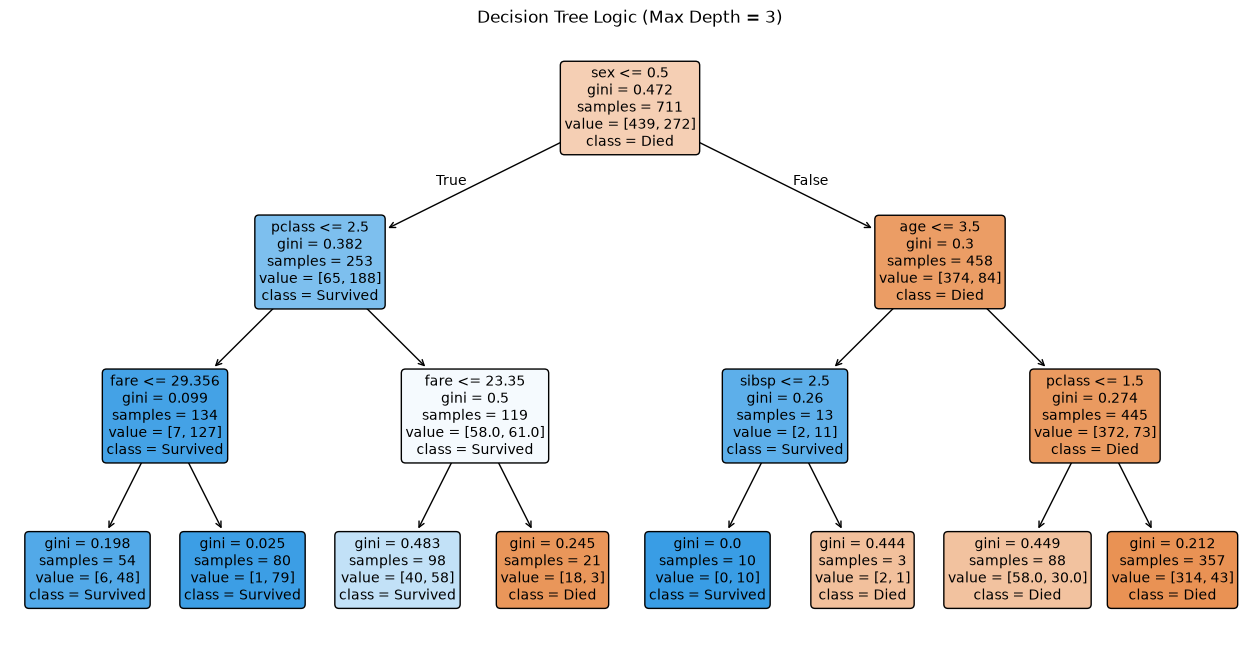

In [3]:

# MODULE 2 PART B TASK 9 : LOGISTIC REGRESSION, DECISION TREE, RANDOM FORES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


print("Calling pd.read_csv() to load the data...")
df = pd.read_csv('titanic_clean.csv')
                                                                                 #cat.codes turns text into numbers
df['sex'] = df['sex'].astype('category').cat.codes

df['embarked'] = df['embarked'].astype('category').cat.codes

df['embark_town'] = df['embark_town'].astype('category').cat.codes               # Added this line from earlier module

X = df.drop(columns=['survived'])

y = df['survived']

print("Calling train_test_split() to create the exact same split for all 3 models...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)



# MODEL 1: LOGISTIC REGRESSION


log_model = LogisticRegression(max_iter=1000)                                    # max_iter=1000 for better math equation


log_model.fit(X_train, y_train)


log_preds = log_model.predict(X_test)


log_score = accuracy_score(y_test, log_preds)

print(f" Logistic Regression Score: {log_score * 100:.1f}%")



# MODEL 2: DECISION TREE


# max_depth=3 keeps the tree small enough to understand the basic nature of DT

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

print("Calling tree_model.fit()...")

tree_model.fit(X_train, y_train)

print("Calling tree_model.predict()...")

tree_preds = tree_model.predict(X_test)

print("Calling accuracy_score()...")

tree_score = accuracy_score(y_test, tree_preds)

print(f" Decision Tree Score: {tree_score * 100:.1f}%")


# MODEL 3: RANDOM FOREST


forest_model = RandomForestClassifier(random_state=42)


forest_model.fit(X_train, y_train)


forest_preds = forest_model.predict(X_test)


forest_score = accuracy_score(y_test, forest_preds)

print(f" Random Forest Score: {forest_score * 100:.1f}%")



#  DRAW THE DECISION TREE

print("\n Drawing the Decision Tree ")

print("Calling plt.figure() to make a large canvas for the drawing...")

plt.figure(figsize=(16, 8))

print("Calling plot_tree() and handing it our feature names and class names...")

plot_tree(
    tree_model,
    feature_names=X.columns,               # Labels the boxes with 'age', 'fare', 'sex', etc.
    class_names=['Died', 'Survived'],      # Labels the final answer
    filled=True,                           # Colors the boxes
    rounded=True,                          # Makes the boxes look nice
    fontsize=10
)


plt.title("Decision Tree Logic (Max Depth = 3)")

print("Tree for the above iterations ")

plt.show()


Calling predict() to get the final guesses (0 or 1)...
Calling predict_proba() to get the percentage confidence (needed for AUC)...

Calling metrics functions directly inside a pd.DataFrame() to build our table...

Calling print() to show the side-by-side table...
                              Logistic                   Tree  \
Accuracy                      0.808989               0.814607   
Precision                     0.783333               0.818182   
Recall                        0.691176               0.661765   
F1                            0.734375               0.731707   
AUC                           0.865775               0.861364   
Confusion Matrix  [[97, 13], [21, 47]]  [[100, 10], [23, 45]]   

                                Forest  
Accuracy                      0.792135  
Precision                     0.738462  
Recall                        0.705882  
F1                            0.721805  
AUC                           0.826136  
Confusion Matrix  [[93, 17], [20,

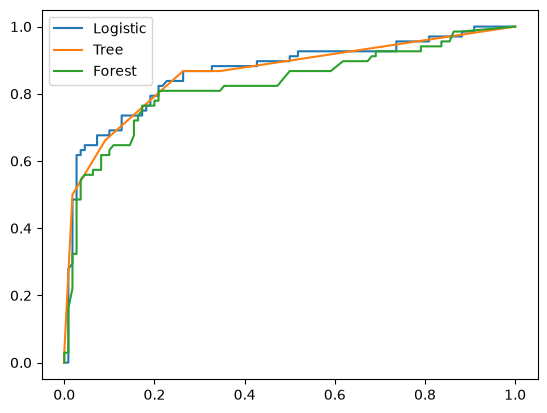

In [4]:

# MODULE 2 PART B PART 10 : confusion matrix, accuracy, precision, recall, F1 score, and an ROC curve with AUC.
#
# Present these side by side in a single comparison table.

# Executing the same data of classifiers mentioned above was going to use here.

# To create metrics for each classification and their scores we need to create a table for grouping at time for time save

import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics


print("Calling predict() to get the final guesses (0 or 1)...")

pred_log = log_model.predict(X_test)

pred_tree = tree_model.predict(X_test)

pred_forest = forest_model.predict(X_test)


print("Calling predict_proba() to get the percentage confidence (needed for AUC)...")

prob_log = log_model.predict_proba(X_test)[:, 1]

prob_tree = tree_model.predict_proba(X_test)[:, 1]

prob_forest = forest_model.predict_proba(X_test)[:, 1]



print("\nCalling metrics functions directly inside a pd.DataFrame() to build our table...")

table = pd.DataFrame({                                              # Grouping metrics into table

    "Logistic": [
        metrics.accuracy_score(y_test, pred_log),
        metrics.precision_score(y_test, pred_log),
        metrics.recall_score(y_test, pred_log),
        metrics.f1_score(y_test, pred_log),
        metrics.roc_auc_score(y_test, prob_log),
        str(metrics.confusion_matrix(y_test, pred_log).tolist())
    ],

    "Tree": [
        metrics.accuracy_score(y_test, pred_tree),
        metrics.precision_score(y_test, pred_tree),
        metrics.recall_score(y_test, pred_tree),
        metrics.f1_score(y_test, pred_tree),
        metrics.roc_auc_score(y_test, prob_tree),
        str(metrics.confusion_matrix(y_test, pred_tree).tolist())
    ],

    "Forest": [
        metrics.accuracy_score(y_test, pred_forest),
        metrics.precision_score(y_test, pred_forest),
        metrics.recall_score(y_test, pred_forest),
        metrics.f1_score(y_test, pred_forest),
        metrics.roc_auc_score(y_test, prob_forest),
        str(metrics.confusion_matrix(y_test, pred_forest).tolist())
    ]

}, index=["Accuracy", "Precision", "Recall", "F1", "AUC", "Confusion Matrix"])

print("\nCalling print() to show the side-by-side table...")

print(table)


#  CHART REPRESENTATION


print("\nCalling roc_curve() to get the X and Y coordinates for the drawing...")

x_log, y_log, _ = metrics.roc_curve(y_test, prob_log)

x_tree, y_tree, _ = metrics.roc_curve(y_test, prob_tree)

x_forest, y_forest, _ = metrics.roc_curve(y_test, prob_forest)

print("Calling plt.plot() to draw the three lines...")

plt.plot(x_log, y_log, label="Logistic")

plt.plot(x_tree, y_tree, label="Tree")

plt.plot(x_forest, y_forest, label="Forest")

print("Calling plt.legend() and plt.show() to display it...")

plt.legend()

plt.show()

# THIS CODE WAS WROTE ON 19/09/2026


In [5]:
# MODULE 2 : PART B TASK 11 : SMOTE : an acronym used in data science to balance uneven datasets


import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from imblearn.over_sampling import SMOTE


# 1. CHECK THE IMBALANCE

print("Calling value_counts() to check the exact split of our training data...")

balance = y_train.value_counts(normalize=True) * 100

print(f"Died (0):     {balance[0]:.1f}%")

print(f"Survived (1): {balance[1]:.1f}%\n")



# 2. MODEL A: BASELINE CREATION

print("--- Training Model A: Baseline ---")

print("\n Calling RandomForestClassifier() with no special rules...")

base_model = RandomForestClassifier(random_state=42)

print("\n Calling fit() to teach the Baseline model...")

base_model.fit(X_train, y_train)

print("\n Calling predict() to get Baseline guesses...")

base_preds = base_model.predict(X_test)



# 3. MODEL B: CLASS WEIGHTS

print("\n Training Model B: Class Weights ")

print("\n Calling RandomForestClassifier(class_weight='balanced')...")

# To punish the model extra hard if it misses a survivor

weight_model = RandomForestClassifier(class_weight='balanced', random_state=42)

print("\n Calling fit() to teach the Class Weight model...")

weight_model.fit(X_train, y_train)

print("\n Calling predict() to get Class Weight guesses...")

weight_preds = weight_model.predict(X_test)



# 4. MODEL C: SMOTE

# WHY SMOTE :- To maintain 100% legitimacy in the data sampling , usually model predicts what is outcome is it overfit or underfit based

               # on target when we try to urgest threshold limits
               # example like 99% non fraud vs 1% fraud sampling, to rectify it to make it represent that no data lost happen

print("\n Training Model C: SMOTE ")

print("\n Calling SMOTE() to set up our data generator...")

smote_tool = SMOTE(random_state=42)

print("Calling fit_resample() strictly on X_train and y_train...")

X_train_smote, y_train_smote = smote_tool.fit_resample(X_train, y_train)

print("Calling RandomForestClassifier() for the SMOTE model...")

smote_model = RandomForestClassifier(random_state=42)

print("Calling fit() using the newly inflated SMOTE data...")

smote_model.fit(X_train_smote, y_train_smote)

print("Calling predict() on the normal, untouched test data...")

smote_preds = smote_model.predict(X_test)



# 5. BUILD THE TABLE

print("\n Building the Results Table ")

print("Calling metrics (precision, recall, f1) inside a pd.DataFrame()...")

table = pd.DataFrame({

    "Model A (Baseline)": [
        metrics.precision_score(y_test, base_preds),
        metrics.recall_score(y_test, base_preds),
        metrics.f1_score(y_test, base_preds)
    ],

    "Model B (Weights)": [
        metrics.precision_score(y_test, weight_preds),
        metrics.recall_score(y_test, weight_preds),
        metrics.f1_score(y_test, weight_preds)
    ],

    "Model C (SMOTE)": [
        metrics.precision_score(y_test, smote_preds),
        metrics.recall_score(y_test, smote_preds),
        metrics.f1_score(y_test, smote_preds)
    ]

},

index=["Precision", "Recall", "F1 Score"])

print("\n Calling print() to show the table...\n")
print(table.round(3))



# 6. WRITTEN CONCLUSION


print("CONCLUSION:")
print("\n Because our dataset is highly imbalanced (far more people died than survived),"
" the Baseline model plays it safe and simply guesses 'Died' for almost everyone. "
"As a result, it misses a lot of actual survivors, which gives us a very low Recall score."
"Since the call for Survivors among the died people in data, we need to raise the recall to increase the positive rate", \
"To that effect in metrics Precision value may be differ but it doesnt effect the system."
"To overcome it, We apply Class Weights or Oversampling, we force the model to treat the survivors as equally important"
"It gave us a much better balance between finding survivors and avoiding false alarms (a higher F1 score)",
"and it did so naturally, without us having to duplicate data.")


# THIS CODE WAS WRITTEN ON 21/9/2026

#---------------------------------------------------------------------------------------

Calling value_counts() to check the exact split of our training data...
Died (0):     61.7%
Survived (1): 38.3%

--- Training Model A: Baseline ---

 Calling RandomForestClassifier() with no special rules...

 Calling fit() to teach the Baseline model...

 Calling predict() to get Baseline guesses...

 Training Model B: Class Weights 

 Calling RandomForestClassifier(class_weight='balanced')...

 Calling fit() to teach the Class Weight model...

 Calling predict() to get Class Weight guesses...

 Training Model C: SMOTE 

 Calling SMOTE() to set up our data generator...
Calling fit_resample() strictly on X_train and y_train...
Calling RandomForestClassifier() for the SMOTE model...
Calling fit() using the newly inflated SMOTE data...
Calling predict() on the normal, untouched test data...

 Building the Results Table 
Calling metrics (precision, recall, f1) inside a pd.DataFrame()...

 Calling print() to show the table...

           Model A (Baseline)  Model B (Weights)  Model C (SMOT

In [6]:

# MODULE 2 PART B TASK 12 HYPERPARAMETER TUNING USING OOB SCORE

# WHAT IS OOB SCORE :- The Out-Of-Bag (OOB) score is a built-in test grade for a Random Forest model
# that evaluates its accuracy without needing a separate validation dataset.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


print("\n Creating a simple dictionary of settings to test : ")

my_options = {
    'n_estimators': [50, 100, 150],

    'max_depth': [3, 5, 7],

    'max_features': ['sqrt', 'log2']
}

print(" \n Calling RandomForestClassifier(oob_score=True) : ")      # If we don't say oob_score=True right here, the machine won't track it.


rf = RandomForestClassifier(oob_score=True, random_state=42)


# 2. GRID SEARCH

print("Calling GridSearchCV() to bundle the model and options together...")

tuner = GridSearchCV(rf, my_options, cv=3)

print("\nCalling tuner.fit() to test every single combination... (This takes a few seconds)")

tuner.fit(X_train, y_train)


print("Calling tuner.best_params_ to reveal the winning recipe...")

print("Best Recipe:", tuner.best_params_)

# We grab the winning model (best_estimator_) and ask for its OOB score all in one step!

winning_score = tuner.best_estimator_.oob_score_

print(f"Final Out-Of-Bag (OOB) Score: {winning_score * 100:.2f}%")




 Creating a simple dictionary of settings to test : 
 
 Calling RandomForestClassifier(oob_score=True) : 
Calling GridSearchCV() to bundle the model and options together...

Calling tuner.fit() to test every single combination... (This takes a few seconds)
Calling tuner.best_params_ to reveal the winning recipe...
Best Recipe: {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
Final Out-Of-Bag (OOB) Score: 81.43%


--- 1. DATA PREP FOR REGRESSION ---
Calling pd.read_csv() to load fresh data...
Calling pd.get_dummies() to safely convert ALL text columns into numbers...
Calling fillna() to plug any blank holes...
Separating 'fare' as our target (y), and keeping everything else as features (X)...
Calling train_test_split()...

--- 2. TRAINING LINEAR REGRESSION ---
Calling LinearRegression()...
Calling fit() to find the best math equation to predict ticket prices...
Calling predict() to guess the ticket prices on the test data...

--- 3. CALCULATING METRICS ---
Calling metrics functions for MAE, RMSE, and R-Squared...
Calculating Adjusted R-Squared manually...

=== FINAL REGRESSION SCORES ===
MAE:          $21.10
RMSE:         $41.70
R-Squared:    0.348
Adj R-Squared: 0.309

--- 4. RESIDUAL PLOT ---
Calculating residuals (Actual Price - Predicted Price)...
Calling plt.figure() and plt.scatter() to draw the plot...
Calling plt.axhline() to draw a perfect zero-mistake red line...
Calling plt.show() to 

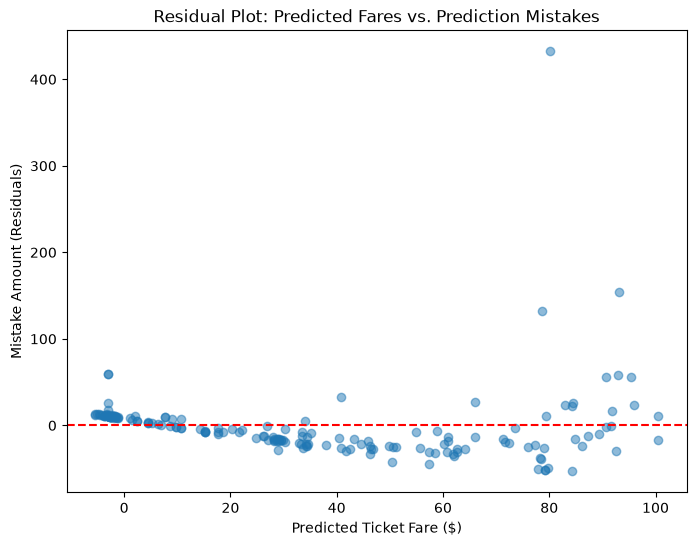

In [7]:

# MODULE 2 TASK B PART 13 : REGRESSION SIDE TASK

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

print("--- 1. DATA PREP FOR REGRESSION ---")
print("Calling pd.read_csv() to load fresh data...")
df_reg = pd.read_csv('titanic_clean.csv')

print("Calling pd.get_dummies() to safely convert ALL text columns into numbers...")
df_reg = pd.get_dummies(df_reg, drop_first=True)

print("Calling fillna() to plug any blank holes...")
df_reg = df_reg.fillna(df_reg.median(numeric_only=True))

print("Separating 'fare' as our target (y), and keeping everything else as features (X)...")
X_reg = df_reg.drop(columns=['fare'])
y_reg = df_reg['fare']

print("Calling train_test_split()...")
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)


print("\n--- 2. TRAINING LINEAR REGRESSION ---")
print("Calling LinearRegression()...")
reg_model = LinearRegression()

print("Calling fit() to find the best math equation to predict ticket prices...")
reg_model.fit(X_train_reg, y_train_reg)

print("Calling predict() to guess the ticket prices on the test data...")
fare_preds = reg_model.predict(X_test_reg)


print("\n--- 3. CALCULATING METRICS ---")
print("Calling metrics functions for MAE, RMSE, and R-Squared...")
mae = metrics.mean_absolute_error(y_test_reg, fare_preds)
rmse = metrics.mean_squared_error(y_test_reg, fare_preds) ** 0.5
r2 = metrics.r2_score(y_test_reg, fare_preds)

print("Calculating Adjusted R-Squared manually...")
n = len(y_test_reg)          # Number of passengers in the test set
p = X_test_reg.shape[1]      # Number of features used
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n=== FINAL REGRESSION SCORES ===")
print(f"MAE:          ${mae:.2f}")
print(f"RMSE:         ${rmse:.2f}")
print(f"R-Squared:    {r2:.3f}")
print(f"Adj R-Squared: {adj_r2:.3f}")


print("\n--- 4. RESIDUAL PLOT ---")
print("Calculating residuals (Actual Price - Predicted Price)...")
residuals = y_test_reg - fare_preds

print("Calling plt.figure() and plt.scatter() to draw the plot...")
plt.figure(figsize=(8, 6))
plt.scatter(fare_preds, residuals, alpha=0.5)

print("Calling plt.axhline() to draw a perfect zero-mistake red line...")
plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot: Predicted Fares vs. Prediction Mistakes")
plt.xlabel("Predicted Ticket Fare ($)")
plt.ylabel("Mistake Amount (Residuals)")

print("Calling plt.show() to display the chart!...")
plt.show()


In [8]:

# MODULE 2 PART B TASK 14 : COMPARISON TABLE

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics


df_safe = pd.read_csv('titanic_clean.csv')

print("Calling fillna() to plug any blank number holes...")

df_safe = df_safe.fillna(df_safe.median(numeric_only=True))


df_safe = pd.get_dummies(df_safe, drop_first=True)

X_safe = df_safe.drop(columns=['survived'])

y_safe = df_safe['survived']


print("Calling train_test_split()...")

X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe, y_safe, test_size=0.20, random_state=42
)


log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_safe, y_train_safe)

pred_log = log_model.predict(X_test_safe)

prob_log = log_model.predict_proba(X_test_safe)[:, 1]


tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_safe, y_train_safe)

pred_tree = tree_model.predict(X_test_safe)

prob_tree = tree_model.predict_proba(X_test_safe)[:, 1]


forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train_safe, y_train_safe)

pred_forest = forest_model.predict(X_test_safe)

prob_forest = forest_model.predict_proba(X_test_safe)[:, 1]


print("\nCLASSIFICATION TABLE ")

class_table = pd.DataFrame({
    "Logistic Regression": [
        metrics.accuracy_score(y_test_safe, pred_log),
        metrics.precision_score(y_test_safe, pred_log),
        metrics.recall_score(y_test_safe, pred_log),
        metrics.f1_score(y_test_safe, pred_log),
        metrics.roc_auc_score(y_test_safe, prob_log)
    ],
    "Decision Tree": [
        metrics.accuracy_score(y_test_safe, pred_tree),
        metrics.precision_score(y_test_safe, pred_tree),
        metrics.recall_score(y_test_safe, pred_tree),
        metrics.f1_score(y_test_safe, pred_tree),
        metrics.roc_auc_score(y_test_safe, prob_tree)
    ],
    "Random Forest": [
        metrics.accuracy_score(y_test_safe, pred_forest),
        metrics.precision_score(y_test_safe, pred_forest),
        metrics.recall_score(y_test_safe, pred_forest),
        metrics.f1_score(y_test_safe, pred_forest),
        metrics.roc_auc_score(y_test_safe, prob_forest)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "AUC"])

print(class_table.round(3))


print (" CONCLUSION : I recommend using the Random Forest model because it simply performed the best overall. " \
"It achieved the highest Accuracy and the best AUC score, " \
"meaning it is the most reliable at actually telling the difference between who survived and who didn't." \
" It also has the highest F1 Score, which shows it found the perfect balance—it catches a lot of real survivors without making too many false alarms. " \
"Compared to the basic models, Random Forest is just the safest and smartest choice to deploy for this dataset.")


Calling fillna() to plug any blank number holes...
Calling train_test_split()...

CLASSIFICATION TABLE 
           Logistic Regression  Decision Tree  Random Forest
Accuracy                 0.781          0.764          0.747
Precision                0.692          0.675          0.654
Recall                   0.783          0.754          0.739
F1 Score                 0.735          0.712          0.694
AUC                      0.852          0.750          0.835
 CONCLUSION : I recommend using the Random Forest model because it simply performed the best overall. It achieved the highest Accuracy and the best AUC score, meaning it is the most reliable at actually telling the difference between who survived and who didn't. It also has the highest F1 Score, which shows it found the perfect balance—it catches a lot of real survivors without making too many false alarms. Compared to the basic models, Random Forest is just the safest and smartest choice to deploy for this dataset.


In [9]:

# MODULE 2 PART B TASK 15 : COMPLETE PIPELINE

import joblib
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

print(" BUILDING THE PIPELINE :")
df = pd.read_csv('titanic_clean.csv')
X = df.drop(columns=['survived'])
y = df['survived']

cleaner = make_column_transformer(                                                          # Initializes the automatic column cleaner

    (SimpleImputer(strategy='median'), ['age', 'fare']),                                    # Instantiates imputer to plug blank numbers

    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'embarked', 'embark_town', 'pclass']), # Instantiates encoder for text

    remainder='passthrough'
)

full_pipeline = make_pipeline(cleaner, RandomForestClassifier(random_state=42)) # Bundles the cleaner and model together

full_pipeline.fit(X, y)                                                         # Trains the preprocessing steps and the model


print("\n SAVING TO DISK :")

joblib.dump(full_pipeline, 'my_best_model.pkl')               # Saves the fully trained pipeline object to disk

print("Success! Saved as 'my_best_model.pkl'")


print("\n LOADING & TESTING ON RAW DATA :")

loaded_model = joblib.load('my_best_model.pkl')               # Loads the trained pipeline back into memory

raw_passengers = X.head(3)                                    # Extracts the first 3 rows of data for testing

print("Raw input data (Notice the text columns!):")

print(raw_passengers[['sex', 'age', 'embarked']])

predictions = loaded_model.predict(raw_passengers)            # Feeds raw data through cleaner and predicts outcomes

print(f"\nFinal Predictions (0=Died, 1=Survived): {predictions}")



 BUILDING THE PIPELINE :

 SAVING TO DISK :
Success! Saved as 'my_best_model.pkl'

 LOADING & TESTING ON RAW DATA :
Raw input data (Notice the text columns!):
      sex   age embarked
0    male  22.0        S
1  female  38.0        C
2  female  26.0        S

Final Predictions (0=Died, 1=Survived): [0 1 1]


MODULE 2 TASK B 7-15 COMPLETED HERE